In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

## Carga del metadata

In [3]:
DATA_DIR = '../HAM10000/archive/'

df = pd.read_csv(DATA_DIR + 'HAM10000_metadata.csv')
df.head()
df['age'] = df['age'].astype('Int64')

## Limpieza de datos

In [ ]:
## Imputar valores nulos con la mediana de cada categoria a la edad
medianas = df.groupby('dx')['age'].median()
df['age'] = df['age'].fillna(df['dx'].map(medianas))

## Distribuciones

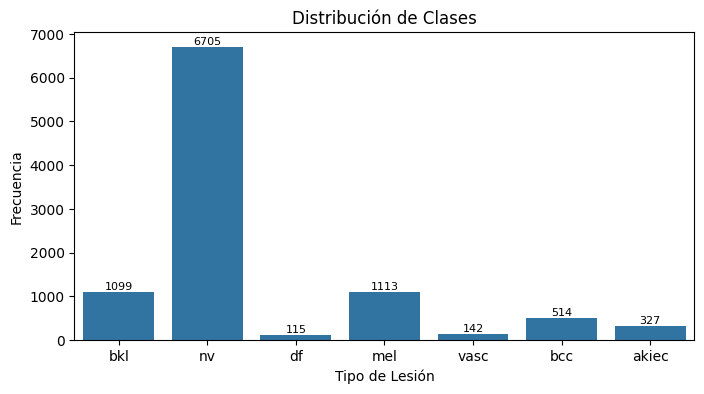

In [5]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x='dx', data=df)
plt.title('Distribución de Clases')
plt.xlabel('Tipo de Lesión')
plt.ylabel('Frecuencia')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontweight='normal',
                fontsize=8)
plt.show()

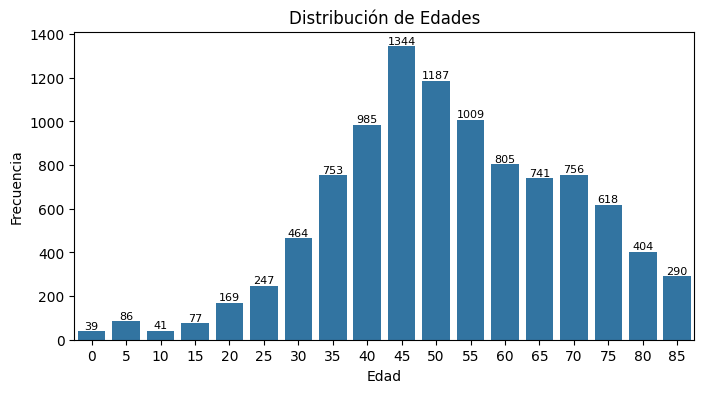

In [6]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x='age', data=df)  # ✅ aquí está la clave
plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontweight='normal',
                fontsize=8)
plt.show()

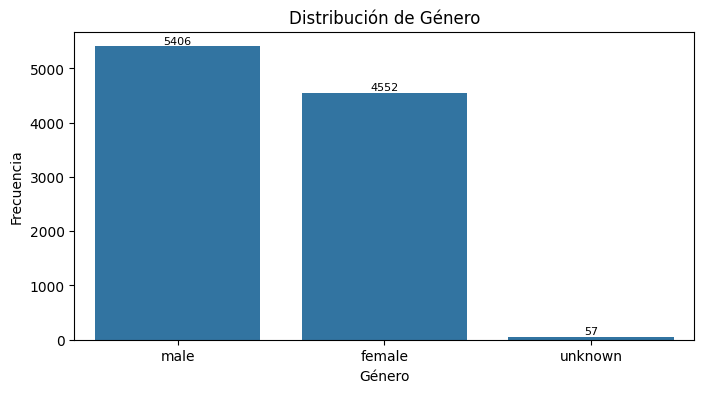

In [7]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x='sex', data=df)
plt.title('Distribución de Género')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontweight='normal',
                fontsize=8)
plt.show()

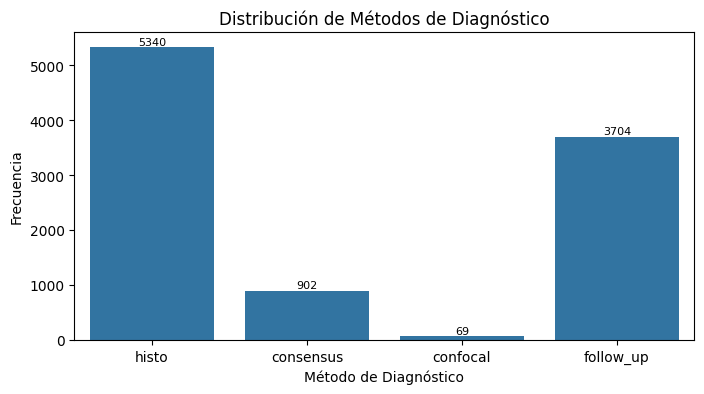

In [8]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x='dx_type', data=df)
plt.title('Distribución de Métodos de Diagnóstico')
plt.xlabel('Método de Diagnóstico')
plt.ylabel('Frecuencia')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontweight='normal',
                fontsize=8)
plt.show()

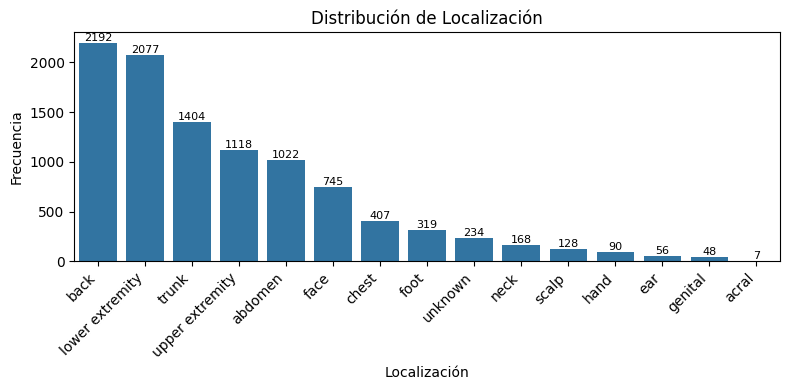

In [9]:
plt.figure(figsize=(8,4))
order = df['localization'].value_counts().index
ax = sns.countplot(x='localization', data=df, order=order)
plt.title('Distribución de Localización')
plt.xlabel('Localización')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontweight='normal',
                fontsize=8)
plt.tight_layout()
plt.show()

# Modelo clásico de Machine Learning (Máquinas de Vectores de Soporte, SVM)

In [ ]:
! python -m pip install imblearn


   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]



In [1]:
import pandas as pd
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Configuración inicial y rutas
# Asegúrate de ajustar esta ruta a la carpeta donde descomprimiste las imágenes
ruta_imagenes = 'D:/MaestriaUNIR/TFM/HAM10000/archive/HAM10000_images/' 
metadata_path = 'D:/MaestriaUNIR/TFM/HAM10000/archive/HAM10000_metadata.csv'

df = pd.read_csv(metadata_path)

# Definimos el nuevo tamaño de las imágenes (ej. 64x64 píxeles para ahorrar memoria)
IMG_SIZE = (64, 64)

# 2. Función para cargar y procesar imágenes
def cargar_y_aplanar_imagenes(df, base_path, size):
    X = []
    # Usamos tqdm para ver una barra de progreso
    for image_id in tqdm(df['image_id'], desc="Cargando imágenes"):
        # Se asume formato .jpg
        img_path = os.path.join(base_path, f"{image_id}.jpg") 
        
        try:
            # Abrir, redimensionar, y convertir a escala de grises (opcional pero reduce dimensiones)
            # Para dermatología, el color importa, así que lo mantenemos en RGB (3 canales)
            img = Image.open(img_path).resize(size)
            img_array = np.array(img)
            
            # Aplanar la imagen: de (64, 64, 3) pasa a un vector 1D de 12288 elementos
            X.append(img_array.flatten())
        except Exception as e:
            print(f"Error cargando la imagen {img_path}: {e}")
            X.append(np.zeros(size[0] * size[1] * 3)) # Placeholder en caso de error
            
    return np.array(X)

print("Iniciando extracción de características visuales...")
X = cargar_y_aplanar_imagenes(df, ruta_imagenes, IMG_SIZE)
y = df['dx'].values

# 3. División de datos (Train / Test)
# Estratificamos para mantener la misma proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de X_train antes de PCA: {X_train.shape}")

# 4. Estandarización de los datos (Crucial para SVM y PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Reducción de Dimensionalidad con PCA
# Mantenemos el 95% de la varianza explicada para reducir ruido y variables innecesarias
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Dimensiones de X_train después de PCA: {X_train_pca.shape}")

# 6. Balanceo de Clases con SMOTE (Solo en el conjunto de entrenamiento)
print("Aplicando SMOTE para balancear las clases...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)

# 7. Entrenamiento del Modelo SVM
# Usamos el kernel RBF y aplicamos class_weight='balanced' como doble protección
print("Entrenando el modelo SVM (esto puede tomar varios minutos)...")
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)

# 8. Evaluación del Modelo
print("Evaluando el modelo en el conjunto de prueba...")
y_pred = svm_model.predict(X_test_pca)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

Iniciando extracción de características visuales...


Cargando imágenes: 100%|██████████| 10015/10015 [00:53<00:00, 188.63it/s]


Dimensiones de X_train antes de PCA: (8012, 12288)
Dimensiones de X_train después de PCA: (8012, 84)
Aplicando SMOTE para balancear las clases...
Entrenando el modelo SVM (esto puede tomar varios minutos)...
Evaluando el modelo en el conjunto de prueba...

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

       akiec       0.42      0.66      0.51        65
         bcc       0.45      0.55      0.50       103
         bkl       0.45      0.55      0.49       220
          df       0.29      0.26      0.27        23
         mel       0.34      0.48      0.39       223
          nv       0.89      0.76      0.82      1341
        vasc       0.43      0.36      0.39        28

    accuracy                           0.68      2003
   macro avg       0.47      0.52      0.48      2003
weighted avg       0.73      0.68      0.70      2003

